<a href="https://colab.research.google.com/github/burningdust/ESAA/blob/main/YB_Session/ESAA_YB_0403(2)_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C_%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [2]:
# 종속 변수와 예측 결과로 혼동 행렬 생성
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y, y_pred)
print(confusion)

[[337  20]
 [ 30 182]]


**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [4]:
# 정확도 : 전체 예측 데이터 건수 중 예측 결과가 동일한 데이터 건수의 비율
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y, y_pred)
print('정확도: {0:.4f}'.format(accuracy)) # 모델이 진단한 환자 중 올바른 진단을 내린 환자의 비율

0.9121265377855887


**정밀도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [16]:
# 정밀도 : Positive로 예측한 데이터 건수 중 실제로 Positive인 데이터 건수의 비율
from sklearn.metrics import precision_score
precision = precision_score(y, y_pred)
print('정밀도: {0:.4f}'.format(precision)) # 모델이 악성(암)이라고 진단한 환자 중 실제 암 환자의 비율

정확도: 0.9010


**재현율의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [20]:
# 재현율 : 실제 Positive인 데이터 건수 중 Positive로 예측한 데이터 건수의 비율
from sklearn.metrics import recall_score
recall = recall_score(y, y_pred)
print('재현율: {0:.4f}'.format(recall)) # 실제 암 환자 중 모델이 악성(암)으로 진단한 환자의 비율

재현율: 0.8585


**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [21]:
# F1 score : 정밀도와 재현율을 결합한 값으로 어느 한 쪽으로 치우치지 않을 때 상대적으로 높은 값을 가짐.
from sklearn.metrics import f1_score
f1 = f1_score(y, y_pred)
print('F1 score: {0:.4f}'.format(f1)) # 정밀도와 재현율 어느 한 쪽으로 치우치지 않고 안정적인 성능을 가진 모델이다.

정확도: 0.8792


**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [23]:
from sklearn.preprocessing import Binarizer
import numpy as np

pred_proba = model_lor.predict_proba(X)
custom_threshold = 0.9
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)
binarizer = Binarizer(threshold=custom_threshold)
y_pred2 = binarizer.fit_transform(pred_proba_1)

In [27]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기
def get_clf_eval(y_test, pred):
  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test, pred)
  precision = precision_score(y_test, pred)
  recall = recall_score(y_test, pred)
  f1 = f1_score(y_test, pred)
  print('오차 행렬')
  print(confusion)
  print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}'.format(
      accuracy, precision, recall, f1))

get_clf_eval(y, y_pred2)

오차 행렬
[[356   1]
 [ 73 139]]
정확도: 0.8699, 정밀도: 0.9929, 재현율: 0.6557, F1: 0.7898


**ROC 곡선 시각화**

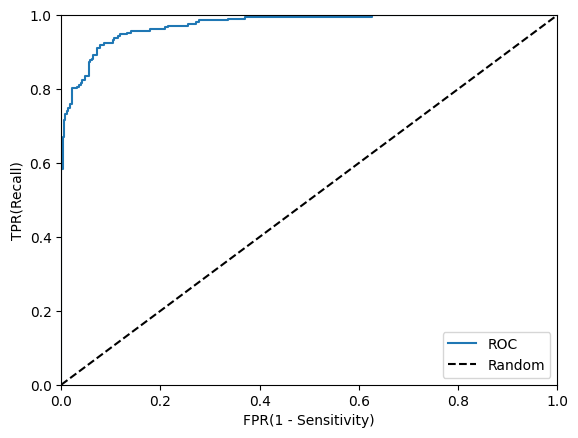

In [32]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fprs, tprs, thresholds = roc_curve(y, pred_proba[:,1])
plt.plot(fprs, tprs, label = 'ROC')
plt.plot([0,1], [0,1], 'k--', label = 'Random')
plt.axis([0,1,0,1])
plt.xlabel('FPR(1 - Sensitivity)')
plt.ylabel('TPR(Recall)')
plt.legend()
plt.show()

**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [34]:
from sklearn.metrics import roc_auc_score
roc_auc_score_lor = roc_auc_score(y, pred_proba[:,1])
print('ROC AUC 값: {0:.4f}'.format(roc_auc_score_lor))

ROC AUC 값: 0.9741
